In [1]:
from mnesis_boilerplate import torch, np, data_cache, Path, RECOMPUTE, DEBUG, get_scores, printfig, approx_equals, SubplotParams, pprint, splt, i_pattern, phi, figpath, Params, asdict, loss_fn, pd, plt, sns
from mnesis_chains import SpikingPattern, HD_SNN
# RECOMPUTE = True
# 
n_char = 100_000_000
n_char = 10_000_000
exp = f'text_{n_char=:.0e}' # HACK
exp

datetag = '2026-08-06'
CUDA: True, Device: NVIDIA RTX A2000 12GB
Using device: cuda


'text_n_char=1e+07'

In [2]:
opt_dict = dict(N_neuron=1024, N_time=2000//DEBUG+41, 
                N_pattern=4, # HACK to make it easier to learn the Lorenz attractor with only 4 patterns
                lif_beta=0.4,
                lif_threshold=.74, do_pinv=True)
opt = Params(**opt_dict)
opt

Params(datetag='2026-08-06', N_neuron=1024, num_delay=41, N_pattern=4, N_time=2041, N_pretime=50, p_A=0.00016, p_flip=0.01, seed=2018, lif_beta=0.4, lif_threshold=0.74, learn_beta=False, learn_threshold=False, do_pinv=True, do_deconv=True, num_epochs=256, num_warmup_epochs=16, base_lr=0.03, final_lr=0.001, delta1=0.01, delta2=1e-05, dropout=0.25, alpha_surrogate=5.0, surrogate_name='FastSigmoid', loss_name='SpikeF1scoreLoss', reset_mechanism='subtract', optimizer='sgd', verbose=False, fig_width=30, fig_height=15, phi=1.61803, N_time_show=512, N_neuron_show=200, N_scan=36)

# working memory with text



### getting text: Wikipedia

In [3]:
%pip install -q -U datasets  

Note: you may need to restart the kernel to use updated packages.


In [4]:
from datasets import load_dataset
# Load a smaller, pre-processed Wikipedia dataset
dataset = load_dataset("wikimedia/wikipedia", "20231101.fr")["train"]
print(dataset[0]["text"][:500])

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/17 [00:00<?, ?it/s]

Antoine Meillet, né le  à Moulins (Allier) et mort le  à Châteaumeillant (Cher), est un philologue français, le principal linguiste français des premières décennies du .

Biographie

Enfance et formation 
Paul Jules Antoine Meillet est d'origine bourbonnaise, fils d'un notaire de Châteaumeillant (Cher). Il naît à Moulins le 11 novembre 1866.

Il passe son enfance à Châteaumeillant, puis fait ses études secondaires au lycée de Moulins.

Étudiant à partir de 1885 à la faculté des lettres de Paris 


In [5]:
dataset['title']

Column(['Antoine Meillet', 'Algèbre linéaire', 'Algèbre générale', 'Algorithmique', 'Politique en Argentine', ...])

In [6]:
len(dataset)

2564646

In [7]:
# titles_with_neur = [article["title"] for article in dataset if "Neur" in article["title"]]
# titles_with_neur

for article in dataset:
    if article["title"] == "Neurosciences computationnelles":
        NeuroComp_text = article["text"]
        break
NeuroComp_text

"Les neurosciences computationnelles (NSC) sont un champ de recherche des neurosciences qui s'applique à découvrir les principes computationnels des fonctions cérébrales et de l'activité neuronale, c'est-à-dire des algorithmes génériques qui permettent de comprendre l'implémentation dans notre système nerveux central du traitement de l'information associé à nos fonctions cognitives. Ce but a été défini en premier lieu par David Marr dans une série d'articles fondateurs.\n \nOn essaie de comprendre le traitement de l'information opéré par le cerveau à l'aide des modèles des sciences informatiques combinés à l'expérimentation et aux simulations numériques.\n\nHistoriquement, un des premiers modèles introduits en neurosciences computationnelles est le modèle « intègre et tire » par Louis Lapicque en 1907. Cet article très influent en neurosciences théoriques et computationnelles introduit un des modèles les plus populaires encore à l'heure actuelle. Cet article a été traduit en anglais à 

In [8]:
print(dataset[0]["text"][:500])

Antoine Meillet, né le  à Moulins (Allier) et mort le  à Châteaumeillant (Cher), est un philologue français, le principal linguiste français des premières décennies du .

Biographie

Enfance et formation 
Paul Jules Antoine Meillet est d'origine bourbonnaise, fils d'un notaire de Châteaumeillant (Cher). Il naît à Moulins le 11 novembre 1866.

Il passe son enfance à Châteaumeillant, puis fait ses études secondaires au lycée de Moulins.

Étudiant à partir de 1885 à la faculté des lettres de Paris 


### tokenization

In [9]:
%pip install -q tiktoken

Note: you may need to restart the kernel to use updated packages.


In [10]:
import tiktoken

enc = tiktoken.get_encoding("cl100k_base")   # tokenizer used by gpt‑3.5‑turbo / gpt‑4

text = "The quick brown fox jumps over 2 lazy dogs."
tokens = enc.encode(text)
print("Token IDs :", tokens)
print("Decoded   :", enc.decode(tokens))
print("Token count:", len(tokens))

Token IDs : [791, 4062, 14198, 39935, 35308, 927, 220, 17, 16053, 12875, 13]
Decoded   : The quick brown fox jumps over 2 lazy dogs.
Token count: 11


In [11]:
for enc_name in tiktoken.list_encoding_names():
    vocab_size = tiktoken.get_encoding(enc_name).max_token_value + 1            # token IDs go from 0 to max_token_value
    print(f'for {enc_name=}, {vocab_size=}')   # → 100256 (≈ 100 k)

for enc_name='gpt2', vocab_size=50257
for enc_name='r50k_base', vocab_size=50257
for enc_name='p50k_base', vocab_size=50281
for enc_name='p50k_edit', vocab_size=50284
for enc_name='cl100k_base', vocab_size=100277
for enc_name='o200k_base', vocab_size=200019
for enc_name='o200k_harmony', vocab_size=201088


In [12]:
# print(f"Concatenated text length: {len(" ".join([article["text"] for article in dataset])):.0e} characters")

`Concatenated text length: 8e+09 characters`

In [13]:
print(f"{n_char=:.0e} characters will be encoded into token IDs")

n_char=1e+07 characters will be encoded into token IDs


In [14]:
filename = data_cache / f"{exp}_wikipedia_fr_token_ids.npy"

if filename.exists() and not RECOMPUTE:
    token_ids = np.load(filename)
else:
    # Extract all articles
    articles = [article["text"] for article in dataset]

    # Concatenate all articles into a single text
    concatenated_text = " ".join(articles)
    print(f"Concatenated text length: {len(concatenated_text):.0e} characters")

    # Encode the first n_char characters of the concatenated text into token IDs
    token_ids = enc.encode(concatenated_text[:n_char])
    np.save(filename, np.array(token_ids, dtype=np.uint32))

In [15]:
token_ids[:100]

array([17555, 63916,  2206, 41984,    11, 38605,   514,   220,  3869,
         386, 11206,  1354,   320,  2460,  1291,     8,  1880, 10237,
         514,   220,  3869,   921, 69628,    64,  3972,   484,   519,
         320,  1163,   261,   705,  1826,   653, 10891, 77828, 55467,
          11,   514, 12717, 39603, 17194, 55467,   951,  6954, 59307,
       35881,  2734,   552,  3930,  6905, 37196,  3257,   648,   271,
        1737,    69,   685,  1880, 18488,   720, 26368,   622,  2482,
       91254,  2206, 41984,  1826,   294,     6,  4775,   483, 93848,
        3458,  1082,    11, 89672,   294, 22827,   539, 12267,   409,
         921, 69628,    64,  3972,   484,   519,   320,  1163,   261,
         570,  7695,  4415, 77422,  3869,   386, 11206,  1354,   514,
         220], dtype=uint32)

In [16]:
np.unique(token_ids).shape

(29532,)

In [17]:
# Compute unique token IDs and their counts
unique_ids, counts = np.unique(token_ids, return_counts=True)

# Sort by frequency (descending order)
sorted_indices = np.argsort(-counts)
sorted_ids = unique_ids[sorted_indices]
sorted_counts = counts[sorted_indices]

# Compute probabilities
total = np.sum(counts)
probs = sorted_counts / total

# Print the top 50 most common tokens
for i in range(min(50, len(sorted_ids))):
    token_id = sorted_ids[i]
    count = sorted_counts[i]
    prob = probs[i]
    token = enc.decode([token_id])

    # Escape special characters
    escaped_token = token.replace("\n", "\\n").replace("\t", "\\t").replace("\r", "\\r")

    print(f"ID {token_id:5d} \t| count {count:7d} \t| probability {prob:.6f} \t| token '{escaped_token}'")

ID    11 	| count   99122 	| probability 0.034743 	| token ','
ID   409 	| count   91277 	| probability 0.031993 	| token ' de'
ID  1208 	| count   49330 	| probability 0.017290 	| token ' la'
ID   220 	| count   40293 	| probability 0.014123 	| token ' '
ID  1880 	| count   39581 	| probability 0.013873 	| token ' et'
ID   326 	| count   35875 	| probability 0.012574 	| token ' l'
ID     6 	| count   33925 	| probability 0.011891 	| token '''
ID   514 	| count   33716 	| probability 0.011818 	| token ' le'
ID    13 	| count   33128 	| probability 0.011611 	| token '.'
ID   978 	| count   31480 	| probability 0.011034 	| token 'é'
ID   951 	| count   29108 	| probability 0.010202 	| token ' des'
ID   294 	| count   26758 	| probability 0.009379 	| token ' d'
ID  3869 	| count   26349 	| probability 0.009235 	| token ' à'
ID  3625 	| count   26301 	| probability 0.009219 	| token ' les'
ID   665 	| count   24726 	| probability 0.008667 	| token ' en'
ID  3930 	| count   23342 	| probabi

In [18]:
# Compute ranks (1-based)
ranks = np.arange(1, len(sorted_counts) + 1)
sorted_ids[:10], sorted_counts[:10], ranks[:10]

(array([  11,  409, 1208,  220, 1880,  326,    6,  514,   13,  978],
       dtype=uint32),
 array([99122, 91277, 49330, 40293, 39581, 35875, 33925, 33716, 33128,
        31480]),
 array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]))

Text(0.5, 1.0, "Zipf's Law: Token Frequency Distribution")

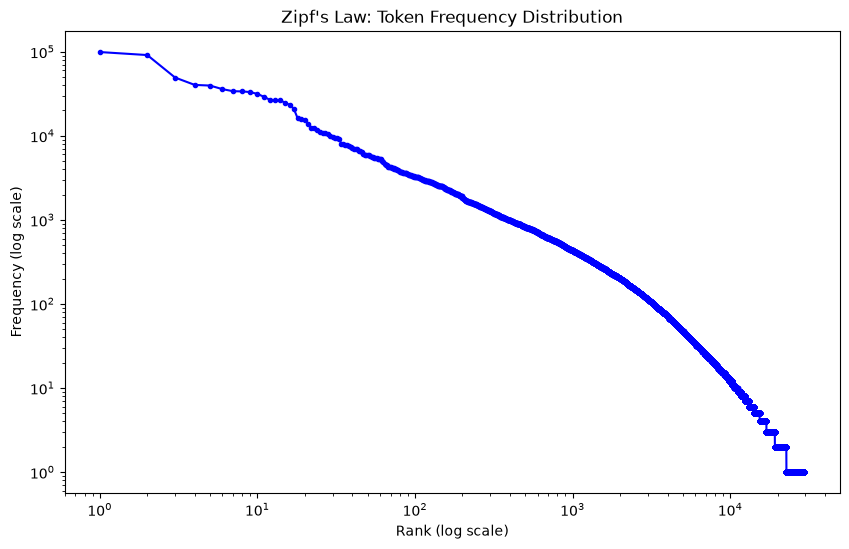

In [19]:

# Log-log plot
plt.figure(figsize=(10, 6))
plt.loglog(ranks, sorted_counts, marker=".", linestyle="-", color="blue")
plt.xlabel("Rank (log scale)")
plt.ylabel("Frequency (log scale)")
plt.title("Zipf's Law: Token Frequency Distribution")


Find the token equivalent of a hapax legomena (tokens with count == 1) - ironically this word is a hapax legomenon itself in this repository.

In [20]:
hapax_ids = unique_ids[counts == 1]

for token_id in hapax_ids[:10]:
    token = enc.decode([token_id])
    escaped_token = token.replace("\n", "\\n").replace("\t", "\\t").replace("\r", "\\r")
    print(f"Hapax legomenon: '{escaped_token}' (ID: {token_id})")

Hapax legomenon: '}' (ID: 92)
Hapax legomenon: '~' (ID: 93)
Hapax legomenon: '�' (ID: 130)
Hapax legomenon: '�' (ID: 132)
Hapax legomenon: '�' (ID: 144)
Hapax legomenon: '�' (ID: 148)
Hapax legomenon: '�' (ID: 168)
Hapax legomenon: '�' (ID: 172)
Hapax legomenon: '\t' (ID: 197)
Hapax legomenon: '**' (ID: 334)


In [21]:
# token # HACK: does not appear as the proper unicode equivalent

## convert as spikes

Based of token IDs frequencies, one produce a codebook to encode any IDs. If we give the most frequent tokens the rows with the smallest weight, the expected activity (average number of active neurons per token) is minimal – reaching lowest Hamming distance (sparsest spiking activity).

In [22]:
def make_codebook(opt, token_ids):
    """
    token_ids : 1‑D numpy array of integer token ids (the whole corpus)

    Returns
        codebook  : torch.uint8 Tensor (num_unique, N_neuron)
        id2rank  : dict token‑id → rank (row index)
        rank2id  : dict rank     → token‑id
        bits2rank: dict tuple(active_neuron_idxs) → rank
    """
    N, dev = opt.N_neuron, opt.device

    # ----- most‑frequent → least‑frequent order -----
    uniq, cnt = np.unique(token_ids, return_counts=True)
    sorted_ids = uniq[np.argsort(-cnt)]          # (num_unique,)
    num_unique = len(sorted_ids)

    # ----- generate exactly `num_unique` masks (0, one‑hot, two‑hot) -----
    masks = [0]                                 # zero‑vector
    for i in range(N):                         # one‑hot
        if len(masks) >= num_unique: break
        masks.append(1 << i)
    if len(masks) < num_unique:                 # two‑hot (only if needed)
        for i in range(N):
            for j in range(i + 1, N):
                masks.append((1 << i) | (1 << j))
                if len(masks) >= num_unique: break
            if len(masks) >= num_unique: break
    assert len(masks) == num_unique

    # ----- integer mask → binary row (uint8) & bits2rank dict -----
    rows = []
    bits2rank = {}
    for r, m in enumerate(masks):
        bits = tuple(i for i in range(N) if (m >> i) & 1)   # (), (i,), (i,j)
        bits2rank[bits] = r
        rows.append(torch.tensor([(m >> i) & 1 for i in range(N)],
                                 dtype=torch.uint8, device=dev))
    codebook = torch.stack(rows, dim=0)                     # (num_unique, N)

    # ----- forward / reverse dictionaries -----
    id2rank = {int(t): r for r, t in enumerate(sorted_ids)}
    rank2id = {r: int(t) for r, t in enumerate(sorted_ids)}

    return codebook, id2rank, rank2id, bits2rank


In [23]:
filename = data_cache / f"{exp}_wikipedia_fr_codebook.pt"
if filename.exists() and not RECOMPUTE:
    ckpt = torch.load(filename, map_location=opt.device)
    codebook, id2rank, rank2id, bits2rank = ckpt["codebook"], ckpt["id2rank"], ckpt["rank2id"], ckpt["bits2rank"]
else:
    codebook, id2rank, rank2id, bits2rank = make_codebook(opt, token_ids)
    codebook = codebook.cpu()
    torch.save({"codebook": codebook,
                "id2rank":  id2rank,
                "rank2id":  rank2id,
                "bits2rank": bits2rank}, filename)
    codebook = codebook.to(opt.device)

codebook, id2rank, rank2id, bits2rank = make_codebook(opt, token_ids)
codebook.device

device(type='cuda', index=0)

In [24]:
print("code‑book shape :", codebook.shape)   # (max_tokens, 256)
print("rank2id shape :", len(rank2id))   # (max_tokens,)
print("most frequent token → rank 0 :", rank2id[0])
print("second most frequent token → rank 1 :", rank2id[1])
print("third most frequent token → rank 2 :", rank2id[2])

code‑book shape : torch.Size([29532, 1024])
rank2id shape : 29532
most frequent token → rank 0 : 11
second most frequent token → rank 1 : 409
third most frequent token → rank 2 : 1208


In [25]:
text = "Le rapide renard brun saute par-dessus 2 chiens paresseux."
fox_tokens = enc.encode(text)
print("Token IDs :", fox_tokens)
print("Decoded   :", enc.decode(fox_tokens))
print("Token count:", len(fox_tokens))

Token IDs : [2356, 76608, 5790, 569, 42707, 829, 1088, 1370, 89429, 355, 220, 17, 26883, 729, 281, 5518, 325, 2249, 13]
Decoded   : Le rapide renard brun saute par-dessus 2 chiens paresseux.
Token count: 19


In [26]:
def encode_batch(token_batch, codebook, id2rank, device):
    """
    token_batch : LongTensor
        (T,)  – single pattern
        (P,T)– P patterns stacked row‑wise
    Returns
        FloatTensor of shape (P, N_neuron, T)  (0.0 / 1.0)
    """
    tb = token_batch.to(device)

    # always work with a 2‑D view (P, T)
    if tb.dim() == 1:
        tb = tb.unsqueeze(0)                     # (1, T)

    P, T = tb.shape

    # token‑id → rank (plain Python dict lookup)
    flat_ranks = torch.tensor([id2rank[int(i)] for i in tb.reshape(-1).tolist()],
                              dtype=torch.long, device=device)

    # pick rows from the compact code‑book
    # -> (P·T, N_neuron)
    binary = codebook[flat_ranks]

    # reshape to (P, T, N_neuron) then permute to (P, N_neuron, T)
    binary = binary.view(P, T, -1).permute(0, 2, 1)

    return binary.float()

tok_tensor = torch.Tensor(fox_tokens).long().to(opt.device)        # shape (9,)
binary_single = encode_batch(tok_tensor, codebook, id2rank, opt.device)

print("tok_tensor shape :", tok_tensor.shape)   # (9,)
print("binary shape :", binary_single.shape)   # (256, 9)
print("First few rows (as 0/1) of the binary matrix:")
print(binary_single[:, :, :5])  # show first 5 tokens


tok_tensor shape : torch.Size([19])
binary shape : torch.Size([1, 1024, 19])
First few rows (as 0/1) of the binary matrix:
tensor([[[0., 0., 0., 0., 0.],
         [0., 1., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         ...,
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]]], device='cuda:0')


In [27]:
batch_tensor = torch.stack([tok_tensor, tok_tensor], dim=0)   # shape (2,9)
binary_batch = encode_batch(batch_tensor, codebook, id2rank, opt.device)

print("\nbinary (batch) shape :", binary_batch.shape)   # (256, 2, 9)



binary (batch) shape : torch.Size([2, 1024, 19])


In [28]:
def decode_batch(binary, bits2rank, rank2id, device=opt.device):
    """
    binary : FloatTensor
        (P, N_neuron, T) – batch of patterns
        or (N_neuron, T) – single pattern
    Returns
        LongTensor of shape (P, T) (or (T,) for a single pattern)
    """
    b = binary.to(device)

    # --------------------------------------------------------------
    # 1️⃣ Normalise to (P, N_neuron, T)
    # --------------------------------------------------------------
    if b.dim() == 2:                 # (N, T) → single pattern
        b = b.unsqueeze(0)           # (1, N, T)

    # after this line we are guaranteed to have (P, N, T)
    P, N, T = b.shape

    # --------------------------------------------------------------
    # 2️⃣ Flatten to (P·T, N) and get the active‑neuron indices
    # --------------------------------------------------------------
    flat = b.permute(0, 2, 1).reshape(-1, N)          # (P·T, N)

    # list of tuples: each tuple contains the positions of the 1‑bits
    bits = [tuple(row.nonzero(as_tuple=False).flatten().tolist())
            for row in flat]

    # --------------------------------------------------------------
    # 3️⃣ tuple → rank → original token id, then reshape back
    # --------------------------------------------------------------
    ids = torch.tensor([rank2id[bits2rank[t]] for t in bits],
                       dtype=torch.long, device=device).view(P, T)

    # squeeze the leading dim if we only had a single pattern
    if P == 1:
        ids = ids.squeeze(0)          # shape (T,)

    return ids

In [29]:
decoded_one = decode_batch(binary_single, bits2rank, rank2id)
print("\nDecoded (single) IDs :", decoded_one.tolist())
print("Round‑trip OK ?",
        np.array_equal(fox_tokens, decoded_one.cpu().numpy()))


Decoded (single) IDs : [2356, 76608, 5790, 569, 42707, 829, 1088, 1370, 89429, 355, 220, 17, 26883, 729, 281, 5518, 325, 2249, 13]
Round‑trip OK ? True


In [30]:
print(f'decoded text = "{enc.decode(decoded_one.cpu().numpy())}"')

decoded text = "Le rapide renard brun saute par-dessus 2 chiens paresseux."


In [31]:
decoded_batch = decode_batch(binary_batch, bits2rank, rank2id)
print("\nDecoded (batch) shape :", decoded_batch.shape)    # (2, 9)
print("First pattern decoded :", decoded_batch[0].tolist())
print("Second pattern decoded :", decoded_batch[1].tolist())


Decoded (batch) shape : torch.Size([2, 19])
First pattern decoded : [2356, 76608, 5790, 569, 42707, 829, 1088, 1370, 89429, 355, 220, 17, 26883, 729, 281, 5518, 325, 2249, 13]
Second pattern decoded : [2356, 76608, 5790, 569, 42707, 829, 1088, 1370, 89429, 355, 220, 17, 26883, 729, 281, 5518, 325, 2249, 13]


## define the pattern generator

In [32]:
len(token_ids) - opt.N_time  + 1

2851003

In [33]:
rng = np.random.default_rng(42)
pattern_idxs_np = rng.choice(len(token_ids) - opt.N_time  + 1, size=opt.N_pattern, replace=False)
pattern_idxs = torch.from_numpy(pattern_idxs_np)
pattern_idxs

tensor([1251243,  254454, 1866184, 2206549])

In [34]:
offsets = torch.arange(opt.N_time).unsqueeze(0)
col_indices = pattern_idxs.unsqueeze(1) + offsets
col_indices

tensor([[1251243, 1251244, 1251245,  ..., 1253281, 1253282, 1253283],
        [ 254454,  254455,  254456,  ...,  256492,  256493,  256494],
        [1866184, 1866185, 1866186,  ..., 1868222, 1868223, 1868224],
        [2206549, 2206550, 2206551,  ..., 2208587, 2208588, 2208589]])

In [35]:
batch_tensor = token_ids[col_indices]   # shape (N_pattern, N_time)
batch_tensor.shape

(4, 2041)

In [36]:
pprint('DEFINING THE PATTERN GENERATOR: Creating a spike pattern generator for text data')

DEFINING THE PATTERN GENERATOR: Creating a spike pattern generator for text data


In [37]:
seed = None
rng = np.random.default_rng(seed)
x= rng.choice(30, size=25, replace=False)
x.sort()
x

array([ 0,  1,  2,  3,  4,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 20,
       21, 23, 24, 25, 26, 27, 28, 29])

In [38]:
cb = {"codebook": codebook, "id2rank":  id2rank, "rank2id":  rank2id, "bits2rank": bits2rank}

In [39]:
class TextSpikingPattern(SpikingPattern):
    def __init__(self, token_ids, cb):
        super().__init__()
        self.desc = "A text spike pattern generator"
        self.token_ids = token_ids # the full corpus as a list of token IDs
        self.n_token = len(token_ids)
        self.cb = cb


    def __call__(self, seed=None, verbose=False):
        """
        Generate N_pattern realizations of length N_time from the spiking pattern of the whole corpus.

        """
        if seed is None:
            if verbose: print("Using default seed from options")
            seed = self.opt.seed
        rng = np.random.default_rng(seed)
        pattern_idxs_np = rng.choice(self.n_token - self.opt.N_time  + 1, size=self.opt.N_pattern, replace=False)
        pattern_idxs = torch.from_numpy(pattern_idxs_np)
        offsets = torch.arange(self.opt.N_time).unsqueeze(0)
        col_indices = pattern_idxs.unsqueeze(1) + offsets
        batch_tensor = torch.Tensor(token_ids[col_indices])
        spikes = encode_batch(batch_tensor, self.cb['codebook'], self.cb['id2rank'], self.opt.device)
        return spikes

tsp = TextSpikingPattern(token_ids, cb)
tsp.init(opt)
spike_pattern = tsp()
spike_pattern.shape

torch.Size([4, 1024, 2041])

## Learn the target

In [40]:
pprint('LEARNING THE TARGET: Training the spiking neural network to learn the Lorenz attractor')

LEARNING THE TARGET: Training the spiking neural network to learn the Lorenz attractor


In [41]:
hd = HD_SNN(opt, TextSpikingPattern(token_ids, cb))
hd.target().shape, opt.N_neuron, opt.N_time

(torch.Size([4, 1024, 2041]), 1024, 2041)

In [42]:
opt

Params(datetag='2026-08-06', N_neuron=1024, num_delay=41, N_pattern=4, N_time=2041, N_pretime=50, p_A=0.00016, p_flip=0.01, seed=2018, lif_beta=0.4, lif_threshold=0.74, learn_beta=False, learn_threshold=False, do_pinv=True, do_deconv=True, num_epochs=256, num_warmup_epochs=16, base_lr=0.03, final_lr=0.001, delta1=0.01, delta2=1e-05, dropout=0.25, alpha_surrogate=5.0, surrogate_name='FastSigmoid', loss_name='SpikeF1scoreLoss', reset_mechanism='subtract', optimizer='sgd', verbose=False, fig_width=30, fig_height=15, phi=1.61803, N_time_show=512, N_neuron_show=200, N_scan=36)

In [ ]:
model_filename = data_cache / f"{hd.opt.datetag}_{exp}_weights.pth"
lock_filename = model_filename.with_suffix('.lock')
if RECOMPUTE:
    model_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
    lock_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
try:
    model_state_dict = torch.load(model_filename, map_location=torch.device(hd.opt.device))
    hd.net.load_state_dict(model_state_dict)
    hd.net.eval()
    lock_filename.unlink(missing_ok=True) # in case the lock file was not unlinked
    print(f"Model weights loaded from {model_filename}") # Add a log message
except FileNotFoundError:
    if not lock_filename.exists():
        print(f"Model file not found: {model_filename}, intitializing the new model.")
        lock_filename.touch(exist_ok=True)
        ##################
        hd.update_weight()
        hd.learn_model()
        ##################
        torch.save(hd.net.state_dict(), model_filename)
        lock_filename.unlink(missing_ok=True)
    else:
        print(f"Model file is locked: {lock_filename}, passing.")

Model file not found: ../cached_data/2026-08-06_text_n_char=1e+07_weights.pth, intitializing the new model.


In [ ]:
with torch.no_grad():
    target = hd.target()
    target_full = torch.nn.functional.pad(target, (opt.N_pretime, opt.N_pretime))
    input_spikes = hd.get_input_spikes()
    _, _, spikes = hd.forward_pass(input_spikes)
    spikes_evoked = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
    target_evoked = target[:, :, hd.opt.num_delay:]

    precision, recall, f1_score = get_scores(spikes_evoked, target_evoked)
    print(f'precision = {precision:.3f}\t recall = {recall:.3f}\t f1_score = {f1_score:.3f} ')

In [ ]:
# TODO reconstruct text from the spikes and compare with the original text. This will require a mapping from neuron addresses back to token IDs and then decoding those token IDs back to text using the tokenizer.

for article in dataset:
    if article["title"] == "Neurosciences computationnelles":
        text = article["text"]
        break
text_token_ids = enc.encode(text)

print("Token IDs :", text_token_ids)
print("Decoded   :", enc.decode(text_token_ids))
print("Token count:", len(text_token_ids))

In [ ]:
tok_tensor = torch.Tensor(text_token_ids).long().to(opt.device)        # shape (9,)
binary_single = encode_batch(tok_tensor, codebook, id2rank, opt.device)

print("tok_tensor shape :", tok_tensor.shape)   # (9,)
print("binary shape :", binary_single.shape)   # (256, 9)
print("First few rows (as 0/1) of the binary matrix:")
print(binary_single[:, :, :5])  # show first 5 tokens

In [ ]:
decoded_one = decode_batch(binary_single, bits2rank, rank2id)
print("\nDecoded (single) IDs :", decoded_one.tolist())
print("Round‑trip OK ?",
        np.array_equal(fox_tokens, decoded_one.cpu().numpy()))

In [ ]:
print(f'decoded text = "{enc.decode(decoded_one.cpu().numpy())}"')

## optimizing learning parameters with optuna

In [ ]:
fig, ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
opt.N_neuron_show = opt.N_neuron
opt.N_time_show = opt.N_time
splt.raster(spikes[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="blue", marker='+', alpha=.5)
splt.raster(target_full[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, facecolor='none', edgecolor='red',  marker='o', alpha=.5)
splt.raster(input_spikes[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="green", marker='x', alpha=.5)
ax.vlines([opt.N_pretime], 0, opt.N_neuron_show, 'r', ls='--')
ax.vlines([opt.N_pretime+opt.num_delay], 0, opt.N_neuron_show, 'b', ls='--')
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Neuron Address")
ax.set_ylim(-1., opt.N_neuron_show + 1.)
spikes.shape, spikes[i_pattern, :, :].sum().item(), target[i_pattern, :, :].sum().item()

In [ ]:
pprint('OPTIMIZING LEARNING PARAMETERS WITH OPTUNA: Hyperparameter optimization using Bayesian search')


In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import warnings
warnings.filterwarnings("ignore", category=optuna.exceptions.ExperimentalWarning,)
optuna_filename = data_cache / f"{opt.datetag}_{exp}_optuna.sqlite3"
lock_filename, study = optuna_filename.with_suffix('.lock'), 1
if RECOMPUTE:
    optuna_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
    lock_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
%ls -l {optuna_filename}

In [ ]:
def objective(trial):    
    new_opt = Params(**opt_dict)

    new_opt.do_deconv = trial.suggest_categorical('do_deconv', [True, False])
    new_opt.do_pinv = trial.suggest_categorical('do_pinv', [True, False])
    new_opt.learn_beta = trial.suggest_categorical('learn_beta', [True, False])
    new_opt.learn_threshold = trial.suggest_categorical('learn_threshold', [True, False])
    new_opt.reset_mechanism = trial.suggest_categorical('reset_mechanism', ['zero', 'subtract'])
    new_opt.optimizer = trial.suggest_categorical('optimizer', ['adamw', 'rmsprop', 'adadelta', 'sgd', 'adam']) # 'adagrad', 'sparseadam', 

    # new_opt.surrogate_name = trial.suggest_categorical('surrogate_name', ['FastSigmoid', 'LeakySpikeOperator', 'ATan', 'Sigmoid', 'SpikeRateEscape'])
    # new_opt.loss_name = trial.suggest_categorical('loss_name', [  'SpikeF1scoreLoss', 'MSELoss', 'L1Loss'])

    new_opt.lif_beta = trial.suggest_float('lif_beta', 0, 1)
    scale = 10
    scale = 3.618    
    new_opt.alpha_surrogate = trial.suggest_float('alpha_surrogate', new_opt.alpha_surrogate / scale, new_opt.alpha_surrogate * scale, log=True)
    new_opt.base_lr = trial.suggest_float('base_lr', new_opt.base_lr / scale, new_opt.base_lr * scale, log=True)
    new_opt.final_lr = trial.suggest_float('final_lr', new_opt.final_lr / scale, new_opt.final_lr * scale, log=True)
    new_opt.delta1 = trial.suggest_float('delta1', new_opt.delta1 / scale, min((new_opt.delta1 * scale, .99)), log=True)
    new_opt.delta2 = trial.suggest_float('delta2', new_opt.delta2 / scale, min((new_opt.delta2 * scale, .99)), log=True)
    new_opt.dropout = trial.suggest_float('dropout', 0, 1)
    new_opt.lif_threshold = trial.suggest_float('lif_threshold', new_opt.lif_threshold / scale, new_opt.lif_threshold * scale, log=True)

    try:
        hd = HD_SNN(new_opt, TextSpikingPattern(token_ids, cb))
        hd.update_weight()
        hd.learn_model(verbose=False)
        
        with torch.no_grad():
            # draw causes (SMs) - hidden to the observer
            input_spikes = hd.get_input_spikes()
            _, _, spikes = hd.forward_pass(input_spikes)
            spikes_ = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
            target_ = hd.target()
            target_ = target_[:, :, hd.opt.num_delay:]
            loss_val = loss_fn(spikes_, target_)

        return loss_val.item()
    except Exception as e:
        print(f"Error occurred: {e}")
        return 1.
        
N_optuna_scan = 100
N_optuna_scan = 200
# N_optuna_scan = 1000
N_optuna_scan = 200 // DEBUG**2

if not lock_filename.exists():
    # 3. Create a study object and optimize the objective function.
    study = optuna.create_study(
        storage=f"sqlite:///{str(optuna_filename)}",
        sampler=optuna.samplers.TPESampler(multivariate=True, warn_independent_sampling=False),
        direction="minimize",
        load_if_exists=True,
        study_name=opt.datetag,
    )

    if len(study.trials) < N_optuna_scan:
        print(f"Optuna file not found or unlocked: {optuna_filename}, starting optimization.")
        lock_filename.touch(exist_ok=True)

        if len(study.trials)>0:
            print("So far, Best params: ", study.best_params, end=', ')
            print("Best value: ", study.best_value)

        print(
            f"Starting optimization on {max(N_optuna_scan - len(study.trials), 0)} trials with {len(study.trials)} existing trials."
        )
        study.optimize(objective, n_trials=max((N_optuna_scan - len(study.trials), 0)), n_jobs=1, show_progress_bar=True)
        lock_filename.unlink(missing_ok=True)
else:
    print(f"Optuna file is locked: {lock_filename}, passing.")
    study = None

In [ ]:
if not study is None:
    study = optuna.load_study(storage=f"sqlite:///{str(optuna_filename)}", study_name=opt.datetag)
else:
    print("Study is None (likely due to lock), skipping load.")

In [ ]:
if not study is None:
    print(f'number of trials in study: {len(study.trials)}')
else:
    print("Study is None, skipping trials display.")

In [ ]:
if not study is None:
    print(50 * "-.")
    print("Best params: ", study.best_params)
    print("Best value: ", study.best_value)
    # print("Best Trial params: ", study.best_trial.params)
else:
    print("Study is None, skipping best-trial summary.")

In [ ]:
if not study is None: 
    import numpy as np
    print("=" * 60)
    print("OPTUNA STUDY ANALYSIS")
    print("=" * 60)

    # 1. Parameter Importances (Ranking of Most Important Parameters)
    print("\n[1] PARAMETER IMPORTANCE RANKING:")
    try:
        importance_dict = optuna.importance.get_param_importances(study)
        for param, imp in sorted(importance_dict.items(), key=lambda item: item[1], reverse=True):
            print(f"{param:<30}: {imp:.3f}")
    except Exception as e:
        print("Error computing importance:", str(e))

    # 2. Best Value and Confidence Intervals for Each Parameter
    print("\n[2] BEST VALUES WITH CONFIDENCE INTERVALS:")

    if not study.trials:
        print("No trials found.")
    else:
        best_trial = study.best_trial
        print(f"\nBest Objective Value: {best_trial.value:.5f}")

        # Collect all valid trials
        completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]

        if not completed_trials:
            print("No completed trials available.")
        else:
            # Get top 10% performing trials for confidence interval estimation
            top_trials = sorted(completed_trials, key=lambda t: t.value, reverse=True)[:max(1, len(completed_trials) // 10)]

            params_all = {pname: [] for pname in best_trial.params}
            for trial in top_trials:
                for pname in params_all:
                    if pname in trial.params:
                        params_all[pname].append(trial.params[pname])

            print("\nEstimated Confidence Intervals (Top 10% Trials):")
            for pname in best_trial.params:
                vals = params_all.get(pname, [])
                if vals:
                    # Check if values are boolean
                    if isinstance(vals[0], bool):
                        # For boolean parameters, show mode and frequency
                        true_count = sum(1 for v in vals if v)
                        false_count = len(vals) - true_count
                        most_common = True if true_count >= false_count else False
                        print(f"{pname}\t: Best={best_trial.params[pname]},\t "
                            f"Most Common={most_common}, True: {true_count}/{len(vals)} ({100*true_count/len(vals):.1f}%)")
                    else:
                        # For numeric parameters, compute percentiles
                        try:
                            low = np.percentile(vals, 5)
                            high = np.percentile(vals, 95)
                            median = np.median(vals)
                            print(f"{pname}\t: Best={best_trial.params[pname]:3e},\t "
                                f"Median={median:>8.3e}, 90% CI=[{low:>8.3e}, {high:>8.3e}]")
                        except Exception as e:
                            print(f"{pname}\t: Best={best_trial.params[pname]},\t "
                                f"Error computing stats: {str(e)}")
                else:
                    print(f"{pname:<30}: No data")

    print("\n" + "=" * 60)

In [ ]:
if not study is None:
    import optuna.visualization.matplotlib as vis
    vis.plot_param_importances(study)
else:
    print("Study is None, skipping parameter-importance plot.")

In [ ]:
if study is not None:

    params = sorted({k for t in study.trials for k in t.params})
    fig, axes = plt.subplots(len(params), 1, figsize=(opt.fig_width, opt.fig_width / phi * len(params)), sharey=True)

    # Garantit un itérable même s'il n'y a qu'un seul paramètre
    if len(params) == 1:
        axes = [axes]

    for ax, pname in zip(axes, params):
        xs = [t.params[pname] for t in study.trials if pname in t.params]
        ys = [t.value for t in study.trials if pname in t.params]

        df = pd.DataFrame({"x": xs, "y": ys})

        # Détection explicite du cas binaire (ex: do_deconv, do_pinv)
        unique_vals = set(df["x"].dropna().tolist())
        is_binary = unique_vals.issubset({True, False, 0, 1}) and len(unique_vals) <= 2
        is_numeric = pd.api.types.is_numeric_dtype(df["x"])

        if is_binary:
            df["x"] = df["x"].astype(bool).map({False: "False", True: "True"})
            ax.scatter(df["x"], df["y"], s=24, alpha=0.8, color="tab:blue", label="Trials")
        elif is_numeric:
            if len(df["x"].unique()) > 1:
                sns.regplot(
                    x="x", y="y", data=df, ax=ax, lowess=True, color="red",
                    line_kws={"lw": 2, "label": "Tendance (LOWESS)"}, scatter=False
                )
            ax.scatter(df["x"], df["y"], s=20, alpha=0.7, color="blue", label="Trials")

            # L'échelle log sur x n'est valide que pour des valeurs strictement positives
            if (df["x"] > 0).all():
                ax.set_xscale("log")
        else:
            df["x"] = df["x"].astype(str)
            ax.scatter(df["x"], df["y"], s=20, alpha=0.7, color="blue", label="Trials")

        ax.set_xlabel(pname)
        ax.set_ylabel("Objective")
        ax.set_yscale("log")

    plt.tight_layout()
else:
    print("Study is None, skipping diagnostic plots.")

## scanning parameters



In [ ]:
pprint('SCANNING PARAMETERS: Systematic evaluation of network and stimulus parameters on model performance')


In [ ]:
import time
opt_scan = Params(datetag = f'{opt.datetag}_{exp}_scan', 
                #   fig_width = 3.25, 
                  **opt_dict)

N_scanning = 13 // DEBUG

scan_dicts= {'N_pattern' : np.linspace(1, 13, N_scanning, dtype=int),
             'N_time' : np.geomspace(500, 3000, N_scanning, dtype=int), #[2**k for k in range(6, 12)],
             'num_delay' : np.linspace(1, 60, N_scanning, dtype=int), # [2, 3, 5, 8, 13, 21, 34, 55, 89],
             'N_neuron' : 2 * np.geomspace(50, 2000, N_scanning, dtype=int), # [55, 89, 144, 233, 377, 610, 987, 1364], #13, 21, 34, 
             'p_A': np.geomspace(0.0002, 0.05, N_scanning, dtype=float) , # [0.0002, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05], #0.00001, 0.00002, 0.00005, 0.0001, .. , 0.1, 0.5
             'lif_threshold': np.linspace(0.6, 1.05, N_scanning, dtype=float), 
             'do_deconv' : [True, False],
             'do_pinv' : [True, False],
            }
label_dicts= {'N_pattern' : 'number of patterns',
             'N_time' : 'Pattern duration',
             'num_delay' : 'Delay range',
             'N_neuron' : 'Presynaptic inputs',
             'p_A': 'Average firing',
             'lif_threshold': 'LIF threshold',
             'do_deconv' : 'Membrane deconvolution',
             'do_pinv' : 'Full pseudo-inverse computation',
            }

N_cv = 10
N_cv = 2
seed = opt_scan.seed
verb = True

for key in scan_dicts:
    print(f"{50*'-'}\nscanning {key=}\n{50*'-'}", )
    filename = data_cache / f'{opt_scan.datetag}_{key}.json'
    lock_filename = filename.with_suffix('.lock')
    if RECOMPUTE : 
        filename.unlink(missing_ok=True) # FORCING RECOMPUTE
        lock_filename.unlink(missing_ok=True) # FORCING RECOMPUTE

    if filename.exists():
        df_scan = pd.read_json(filename, orient='records')
    else:
        measure_columns = [key, 'i_cv', 'loss', 'time']
        df_scan = pd.DataFrame([], columns=measure_columns)

    if not lock_filename.exists():
        lock_filename.touch(exist_ok=True)
        # checking if everything is already computed
        i_loc = 0
        verb = False
        # do print the progress if any item is not computed
        verb = any(((df_scan[key] == value) & (df_scan["i_cv"] == i_cv)).empty 
                   for value in scan_dicts[key] for i_cv in range(N_cv))
        for i_value, value in enumerate(scan_dicts[key]):
            for i_cv in range(N_cv):
                # Check if there's already a row with the same key value and i_cv
                mask = approx_equals(df_scan[key], value) & (df_scan["i_cv"] == i_cv)

                if df_scan[mask].empty :
                    if verb: print(f'|{i_cv=}| {i_value + 1}/{len(scan_dicts[key])}', end='\t')
                    # create a new row with time zero to allow concurrent access to the file by other processes
                    df_scan.loc[i_loc] = {key:value, 'i_cv':i_cv, 'loss':float('inf'), 'time':0.0}
                    df_scan.to_json(filename, orient='records', indent=2)

                    # tic
                    since = time.time()
                    new_dict = asdict(opt_scan)
                    new_dict[key] = value
                    new_dict['seed'] = seed
                    seed += 1 # to have a different seed for each CV, but still reproducible                    
                    new_opt = Params(**new_dict)
                    new_hd = HD_SNN(new_opt, TextSpikingPattern(token_ids, cb))
            
                    new_hd.update_weight()
                    new_hd.learn_model(verbose=False)

                    # test it
                    try:
                        with torch.no_grad():
                            input_spikes = new_hd.get_input_spikes(p_A=new_hd.opt.p_A, N_pretime=new_hd.opt.N_pretime, N_trigger_time=new_hd.opt.num_delay, N_time=new_hd.opt.N_time)
                            _, _, spikes = new_hd.forward_pass(input_spikes)
                            spikes_ = spikes[:, :, (new_hd.opt.N_pretime+new_hd.opt.num_delay):(-new_hd.opt.N_pretime)]
                            target_ = new_hd.target()[:, :, new_hd.opt.num_delay:]
                            loss_val = loss_fn(spikes_, target_).item()
                    except Exception as e:
                        print(f"Error during evaluation: {e}")
                        loss_val = float('inf')  # Assign a large loss value to indicate failure
                        
                    # toc
                    elapsed_time = time.time() - since
        
                    if verb: 
                        print(f'|{key=}:{value=:.3e} \t| loss={loss_val:.3f}', end='\t')
                        print(f"| completed in {elapsed_time // 60:.1f}m {elapsed_time % 60:.1f}s |")

                    df_scan = pd.read_json(filename, orient='records')
                    mask = approx_equals(df_scan[key], value) & (df_scan["i_cv"] == i_cv)
                    df_scan[['loss', 'time']] = df_scan[['loss', 'time']].astype(float)
                    df_scan.loc[mask, ['loss', 'time']] = [loss_val, elapsed_time]
                    df_scan.to_json(filename, orient='records', indent=2)
                else:
                    if verb: 
                        print(f'|{key=}:{value=:.3e} \t| already computed for i_cv={i_cv}, skipping.', end='\t')
                        print(f"| completed in {df_scan[mask]['time'].values[0] // 60:.1f}m {df_scan[mask]['time'].values[0] % 60:.1f}s |")
                i_loc += 1
        lock_filename.unlink(missing_ok=True)


In [ ]:
from matplotlib import ticker
subplotpars_scan = SubplotParams(left=0.125, right=.95, bottom=0.25, top=.975)
custom_style = {
    'axes.spines.left': True,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'axes.spines.bottom': True,
}

for key in scan_dicts:
    print(f"{50*'-'}\nscanning {key=}\n{50*'-'}", )
    filename = data_cache / f'{opt_scan.datetag}_{key}.json'
    lock_filename = filename.with_suffix('.lock')
    if not lock_filename.exists() and filename.exists():
        print(f'Reading {filename=}...')
        df_scan = pd.read_json(filename)
        print(df_scan)
        # https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html?highlight=errorbar#visualization-errorbars
        fig, ax = plt.subplots(subplotpars=subplotpars_scan)
        gp_scan = df_scan[[key, 'loss']].groupby([key])
        means = gp_scan.mean()
        errors = gp_scan.std()

        with plt.style.context(custom_style):
            means.plot.bar(yerr=errors, ax=ax, capsize=4, rot=-60, legend=False, alpha=.5)

        ax.set_ylabel('Loss')
        ax.set_xlabel(label_dicts[key])

        # ax.set_xscale('logit')
        ax.set_ylim(0, 1)
        if key in ['p_A']:
            ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
            ax.xaxis.get_major_formatter().set_scientific(True)
            ax.xaxis.get_major_formatter().set_powerlimits((0,0))
        #fig = ax.get_figure()
        printfig(fig, f'scan_{exp}_{key}', fig_height=opt_scan.fig_height, fig_width=opt_scan.fig_width, figpath=figpath)
